In [4]:
import numpy as np
import matplotlib.pyplot as plt

## Distância de Variação Total

In [5]:
def total_variation(mu, pi):
    return 0.5 * np.sum(np.abs(mu - pi))

## Grafo em anel (125 vértices)

In [7]:
def ring_graph(n=125):
    P = np.zeros((n, n))

    for i in range(n):
        P[i, i] = 1/2
        P[i, (i - 1) % n] = 1/4
        P[i, (i + 1) % n] = 1/4

    # distribuição estacionária uniforme
    pi = np.ones(n) / n

    return P, pi

## Árvore binária cheia (127 vértices)

In [20]:
def binary_tree_graph(n=127):
    P = np.zeros((n, n))

    for v in range(1, n + 1):
        neighbors = []

        # pai
        if v != 1:
            neighbors.append(v // 2)

        # filhos
        if 2 * v <= n:
            neighbors.append(2 * v)

        if 2 * v + 1 <= n:
            neighbors.append(2 * v + 1)

        d = len(neighbors)

        # probabilidade de ficar parado
        P[v - 1, v - 1] = 1/2

        # vizinhos
        for u in neighbors:
            P[v - 1, u - 1] = 1 / (2 * d)

    # distribuição estacionária
    # pi_i = d_i / (2m), com m = 126

    pi = np.zeros(n)

    for v in range(1, n + 1):
        d = 0

        if v != 1:
            d += 1

        if 2 * v <= n:
            d += 1

        if 2 * v + 1 <= n:
            d += 1

        pi[v - 1] = d / 252

    return P, pi

## Grid 11x11

In [16]:
def grid_graph(size=11):
    n = size * size
    P = np.zeros((n, n))

    def idx(i, j):
        return i * size + j

    degrees = np.zeros(n)

    for i in range(size):
        for j in range(size):

            v = idx(i, j)
            neighbors = []

            if i > 0:
                neighbors.append(idx(i - 1, j))

            if i < size - 1:
                neighbors.append(idx(i + 1, j))

            if j > 0:
                neighbors.append(idx(i, j - 1))

            if j < size - 1:
                neighbors.append(idx(i, j + 1))

            d = len(neighbors)
            degrees[v] = d

            # preguiça
            P[v, v] = 1/2

            for u in neighbors:
                P[v, u] = 1 / (2 * d)

    pi = degrees / 440

    return P, pi

## Simulação

In [17]:
def simulate(P, pi, T=1000):

    n = len(pi)

    # começa concentrado no vértice 1
    mu = np.zeros(n)
    mu[0] = 1

    distances = []

    for t in range(T + 1):

        distances.append(total_variation(mu, pi))

        # evolução da cadeia
        mu = mu @ P

    return np.array(distances)

## Construção dos grafos

In [21]:
P_ring, pi_ring = ring_graph()
P_tree, pi_tree = binary_tree_graph()
P_grid, pi_grid = grid_graph()

## Simulações

In [22]:
T = 1000

ring_dist = simulate(P_ring, pi_ring, T)
tree_dist = simulate(P_tree, pi_tree, T)
grid_dist = simulate(P_grid, pi_grid, T)

## Gráfico

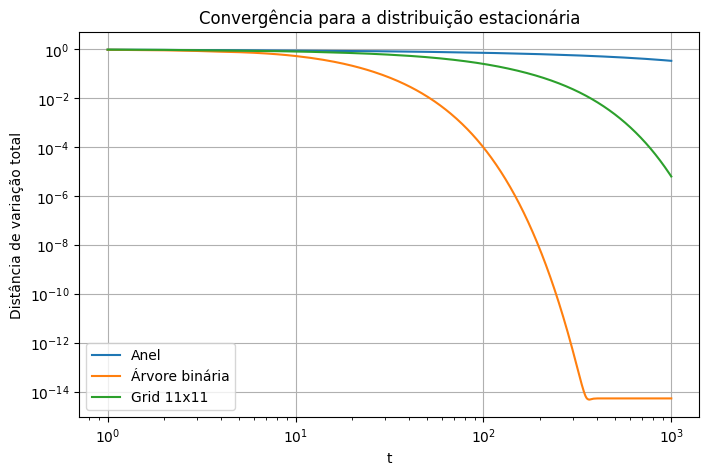

In [23]:
t_vals = np.arange(T + 1)

plt.figure(figsize=(8,5))

plt.loglog(t_vals[1:], ring_dist[1:], label='Anel')
plt.loglog(t_vals[1:], tree_dist[1:], label='Árvore binária')
plt.loglog(t_vals[1:], grid_dist[1:], label='Grid 11x11')

plt.xlabel('t')
plt.ylabel('Distância de variação total')
plt.title('Convergência para a distribuição estacionária')

plt.legend()
plt.grid(True)

plt.show()